# Long-rollout stability

The higher-resolution NeuralGCM models make the best short-range forecasts,
but they are *not* stable for long integrations; the coarser models are. The
published guidance ([checkpoints.md](https://github.com/neuralgcm/neuralgcm/blob/main/docs/checkpoints.md))
gives the reliable unmodified-rollout horizons:

| model | documented stable horizon |
|---|---|
| **1.4° stochastic** | ~6 months |
| **1.4° deterministic** | ~2 years (enhanced by [fixing mean log surface pressure](checkpoint_modifications.ipynb)) |
| **2.8° stochastic** (precip / evap) | ~20 years (atmosphere-only) |
| 0.7° / higher resolution | days — weather only, *not* seasonally stable |

This notebook drives the stable models far past the 4-day forecasts in the
other notebooks and tracks whether they stay physical. It runs two cases —
the recommended **1.4° stochastic** model for **6 months**, and the
**2.8° precipitation** model for **2 years** (a slice of its 20-year
horizon) — and for each plots global stability indicators over time, plus
T850 snapshots and the zonal-mean jet at the start vs. the end.

Real ERA5 sea-surface-temperature and sea-ice forcing is supplied over the
whole period (monthly cadence — a real seasonal cycle), since NeuralGCM
models only the atmosphere. Needs network access (checkpoints + ERA5,
anonymous GCS) and a GPU. The two runs take roughly 15 minutes each.

In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import xarray

from dinosaur_torch import horizontal_interpolation, xarray_utils
import neuralgcm_torch as neuralgcm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
ERA5_PATH = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
full_era5 = xarray.open_zarr(ERA5_PATH, chunks=None, storage_options=dict(token='anon'))
G = 9.80665
SQRT4PI = float(np.sqrt(4 * np.pi))

## Helpers

Loading, forcing setup, the stability indicators, and the rollout loop.

In [3]:
from neuralgcm_torch import pretrained


def load_model(model_name):
  """Load a published checkpoint (Hub download or local checkpoints/ copy)."""
  path = pretrained.fetch_checkpoint(
      model_name, local_root='checkpoints')
  return neuralgcm.PressureLevelModel.from_checkpoint(path, device=device)


def setup_forcing(model, start, horizon_days):
  """Initial state at `start` and time-varying SST/sea-ice over the run.

  Forcings are pulled at monthly cadence (the real seasonal cycle) and
  given the 24-hour lag NeuralGCM expects; `advance` picks the nearest in
  time at every step.
  """
  rg = horizontal_interpolation.ConservativeRegridder(
      xarray_utils.grid_spec_from_dataset(full_era5), model.data_grid,
      skipna=True, device=device)
  regrid = lambda ds: xarray_utils.fill_nan_with_nearest(
      xarray_utils.regrid_horizontal(ds, rg))
  inputs_ds = full_era5[model.input_variables + model.forcing_variables].sel(
      time=start).compute()
  ftimes = np.arange(start, start + np.timedelta64(horizon_days + 31, 'D'),
                     np.timedelta64(30, 'D'))
  forcing_ds = (
      full_era5[model.forcing_variables]
      .sel(time=ftimes, method='nearest')
      .pipe(xarray_utils.selective_temporal_shift,
            variables=model.forcing_variables, time_shift='24 hours')
      .compute())
  return (model.inputs_from_xarray(regrid(inputs_ds)),
          model.forcings_from_xarray(regrid(forcing_ds)))

In [4]:
def make_indicators(model):
  """Returns a function mapping a decoded state to scalar global diagnostics."""
  lat = model.latitudes
  w = np.cos(np.deg2rad(lat)); w = torch.as_tensor(
      w / w.mean(), device=device, dtype=model.dtype)
  lev = model.data_levels.astype(float)
  i850 = int(np.argmin(abs(lev - 850))); i500 = int(np.argmin(abs(lev - 500)))
  p_pa = torch.as_tensor(lev * 100.0, device=device, dtype=model.dtype)
  gmean = lambda f2d: float((f2d * w).mean())  # area-weighted global mean

  def indicators(out, state, lsp00_initial):
    T, U, V = out['temperature'], out['u_component_of_wind'], out['v_component_of_wind']
    Z, Q = out['geopotential'], out['specific_humidity']
    # global-mean surface-pressure drift (% of initial) from the (0, 0) mode
    # of the dynamical log surface pressure (see checkpoint_modifications)
    lsp00 = float(state.state.log_surface_pressure[..., 0, 0].reshape(-1)[0])
    rec = dict(
        T850=gmean(T[i850]),                          # K
        Z500=gmean(Z[i500]) / G,                      # m
        sp_drift_pct=(lsp00 - lsp00_initial) / SQRT4PI * 100.0,
        max_wind_850=float(torch.sqrt(U[i850] ** 2 + V[i850] ** 2).max()),  # m/s
        KE_850=gmean(0.5 * (U[i850] ** 2 + V[i850] ** 2)),  # m^2/s^2
        TCWV=gmean(torch.trapz(Q, p_pa, dim=0) / G),  # kg/m^2
    )
    if 'precipitation_cumulative_mean' in out:        # precip models only
      rec['precip_cumulative_m'] = gmean(out['precipitation_cumulative_mean'][0])
    return rec
  return indicators


def run_stability(model, inputs, forcings, horizon_days, out_every_days,
                  rng=0, snapshot_fracs=(0.0, 0.5, 1.0)):
  """Free-run the model, recording indicators every `out_every_days` and a
  few decoded snapshots. Uses a manual advance loop (not `unroll`) so only
  scalars and a handful of frames are kept in memory."""
  indicators = make_indicators(model)
  dt_hours = model.timestep / np.timedelta64(1, 'h')
  inner = int(round(out_every_days * 24 / dt_hours))
  n_out = int(round(horizon_days / out_every_days))
  snap_idx = {int(round(f * (n_out - 1))) for f in snapshot_fracs}

  state = model.encode(inputs, forcings, rng=rng)
  lsp00_0 = float(state.state.log_surface_pressure[..., 0, 0].reshape(-1)[0])
  model.compile(state, forcings)  # ~5x faster stepping; stochastic part stays eager

  recs, days, snaps = [], [], {}
  t0 = time.perf_counter()
  for i in range(n_out):
    for _ in range(inner):
      state = model.advance(state, forcings)
    out = model.decode(state, forcings)
    recs.append(indicators(out, state, lsp00_0))
    day = (i + 1) * out_every_days
    days.append(day)
    if i in snap_idx:
      snaps[day] = model.data_to_xarray(
          {k: v.unsqueeze(0) for k, v in out.items() if k != 'sim_time'},
          times=[0]).isel(time=0)
  if device == 'cuda':
    torch.cuda.synchronize()
  return dict(
      days=np.array(days),
      series={k: np.array([r[k] for r in recs]) for k in recs[0]},
      snaps=snaps, elapsed=time.perf_counter() - t0)

In [5]:
_LABELS = {
    'T850': 'global-mean T850 (K)',
    'Z500': 'global-mean Z500 (m)',
    'sp_drift_pct': 'surface-pressure drift (%)',
    'max_wind_850': 'max |wind| at 850 (m/s)',
    'KE_850': 'global-mean KE at 850 (m²/s²)',
    'TCWV': 'global-mean TCWV (kg/m²)',
    'precip': 'global-mean precip (mm/day)',
}


def plot_indicators(result, title):
  s = dict(result['series']); days = result['days']
  if 'precip_cumulative_m' in s:  # cumulative metres -> mm/day rate
    cumul = s.pop('precip_cumulative_m')
    step_days = days[1] - days[0]
    s['precip'] = np.diff(cumul, prepend=cumul[0]) * 1000.0 / step_days
  keys = [k for k in _LABELS if k in s]
  x = days / 365.0 if days[-1] > 400 else days
  xlabel = 'forecast year' if days[-1] > 400 else 'forecast day'
  ncol = 3; nrow = int(np.ceil(len(keys) / ncol))
  fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3 * nrow), squeeze=False)
  for ax, k in zip(axes.flat, keys):
    ax.plot(x, s[k]); ax.set_title(_LABELS[k]); ax.set_xlabel(xlabel)
    ax.grid(alpha=0.3)
  for ax in axes.flat[len(keys):]:
    ax.set_visible(False)
  fig.suptitle(title, fontsize=13); fig.tight_layout()


def plot_t850_snapshots(result, title):
  snaps = result['snaps']; days = sorted(snaps)
  lev = snaps[days[0]].level; i850 = int(np.argmin(abs(lev.values - 850)))
  fig, axes = plt.subplots(1, len(days), figsize=(5 * len(days), 3.2),
                           squeeze=False)
  for ax, d in zip(axes[0], days):
    t = snaps[d]['temperature'].isel(level=i850)
    im = t.plot(ax=ax, x='longitude', y='latitude', add_colorbar=False,
                cmap='RdBu_r', robust=True)
    ax.set_title(f'T850, day {d}')
  fig.colorbar(im, ax=axes, shrink=0.8, label='K')
  fig.suptitle(title, fontsize=13)


def plot_zonal_wind(result, title):
  snaps = result['snaps']; days = sorted(snaps); first, last = days[0], days[-1]
  fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
  vmax = 40
  for ax, d in zip(axes, (first, last)):
    zm = snaps[d]['u_component_of_wind'].mean('longitude')
    im = ax.contourf(zm.latitude, zm.level, zm.values,
                     levels=np.linspace(-vmax, vmax, 17), cmap='RdBu_r',
                     extend='both')
    ax.set_title(f'zonal-mean zonal wind, day {d}')
    ax.set_xlabel('latitude'); ax.invert_yaxis()
  axes[0].set_ylabel('pressure (hPa)')
  fig.colorbar(im, ax=axes, shrink=0.85, label='m/s')
  fig.suptitle(title, fontsize=13)

## Seasonal stability: 1.4° stochastic, 6 months

The recommended weather model, run free from a February initial state
through the following August — a full seasonal swing, at its documented
6-month horizon.

In [6]:
model_14s = load_model('stochastic_1_4_deg')
start = np.datetime64('2020-02-14T00')
inputs_a, forcings_a = setup_forcing(model_14s, start, horizon_days=183)
result_a = run_stability(model_14s, inputs_a, forcings_a,
                         horizon_days=183, out_every_days=3, rng=0)
print(f"ran 6 months in {result_a['elapsed']:.0f}s; "
      f"all finite: {np.isfinite(np.concatenate(list(result_a['series'].values()))).all()}")

ran 6 months in 498s; all finite: True


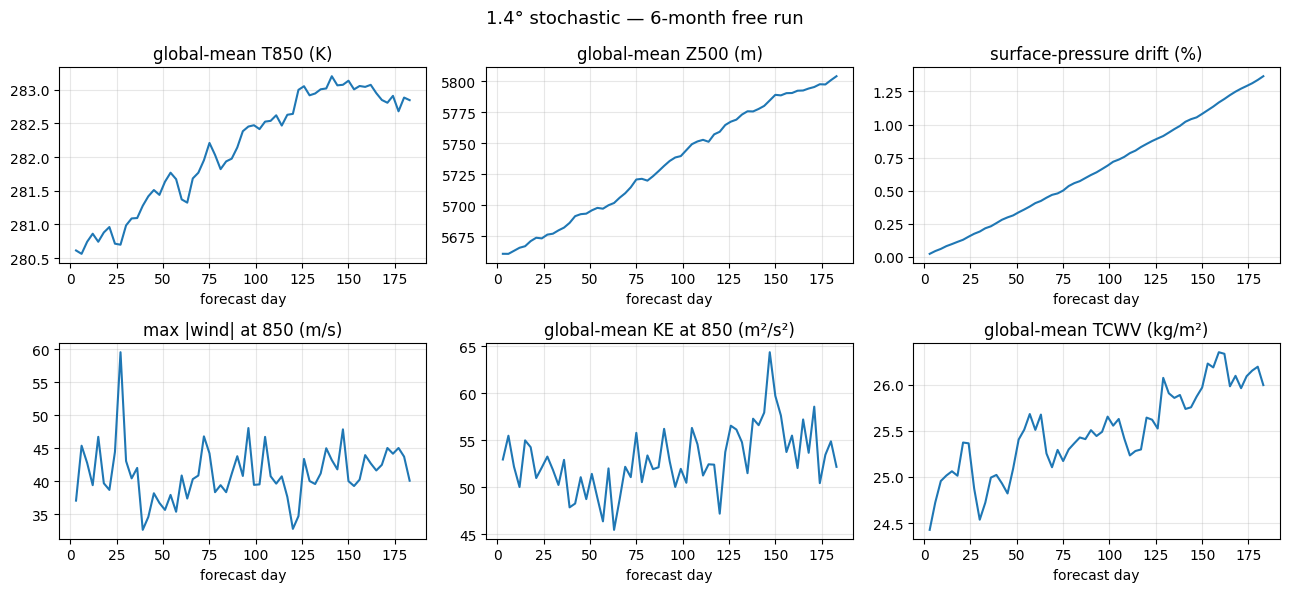

In [7]:
plot_indicators(result_a, '1.4° stochastic — 6-month free run')

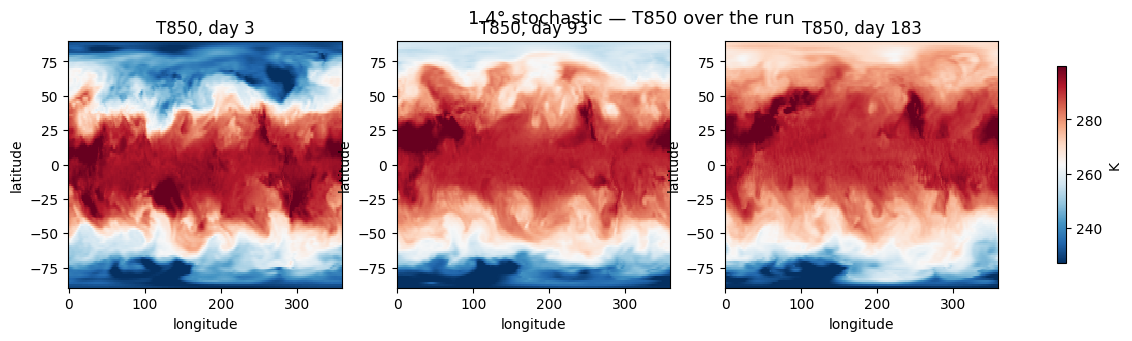

In [8]:
plot_t850_snapshots(result_a, '1.4° stochastic — T850 over the run')

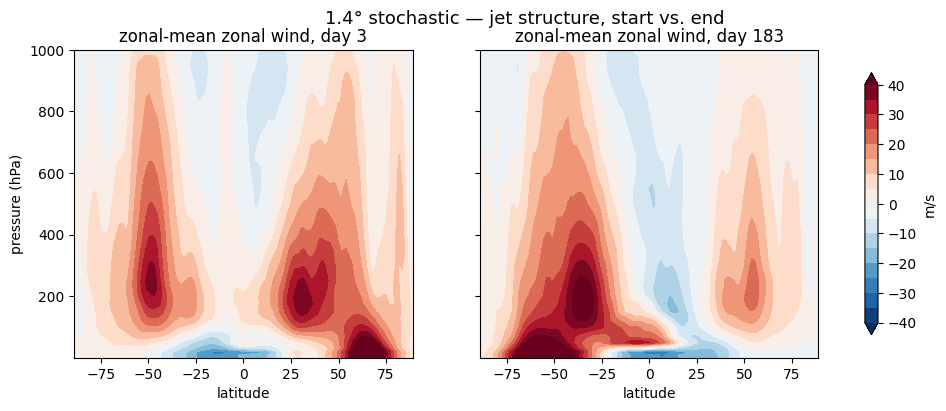

In [9]:
plot_zonal_wind(result_a, '1.4° stochastic — jet structure, start vs. end')

## Climate-scale stability: 2.8° precipitation, 2 years

The 2.8° precipitation model is stable for ~20 years; here it runs for 2
(eight seasons) to show climate-scale stability and that the global-mean
precipitation rate stays near the observed ~3 mm/day. Set
`horizon_days=365*20` to reproduce the full documented horizon.

In [10]:
model_28p = load_model('stochastic_precip_2_8_deg')
inputs_b, forcings_b = setup_forcing(model_28p, start, horizon_days=730)
result_b = run_stability(model_28p, inputs_b, forcings_b,
                         horizon_days=730, out_every_days=5, rng=0)
print(f"ran 2 years in {result_b['elapsed']:.0f}s; "
      f"mean precip "
      f"{np.diff(result_b['series']['precip_cumulative_m']).mean()*1000/5:.2f} mm/day")

ran 2 years in 617s; mean precip 3.02 mm/day


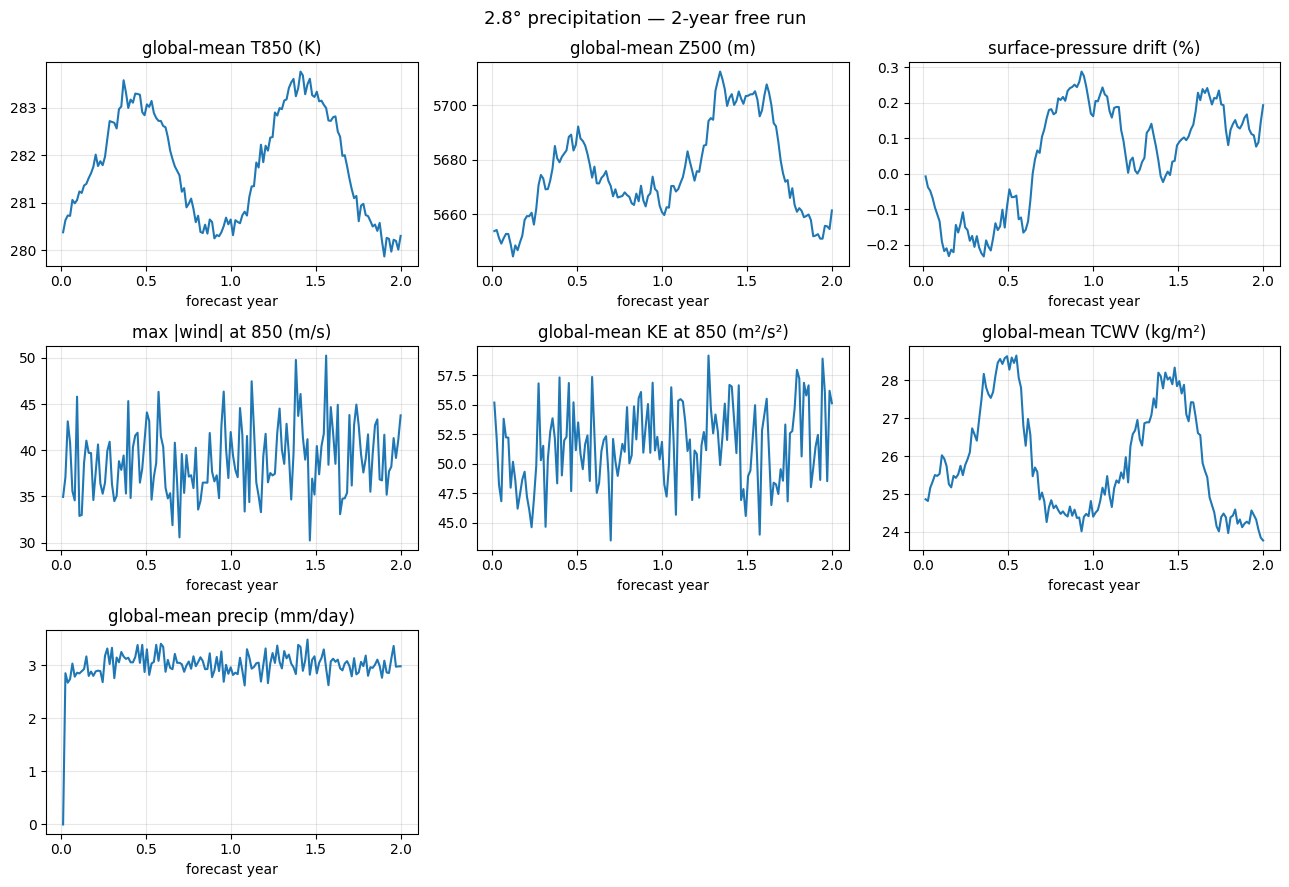

In [11]:
plot_indicators(result_b, '2.8° precipitation — 2-year free run')

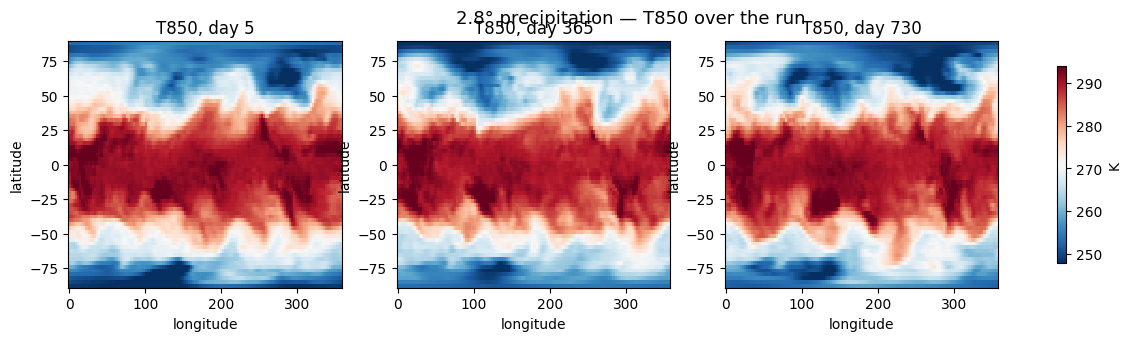

In [12]:
plot_t850_snapshots(result_b, '2.8° precipitation — T850 over the run')

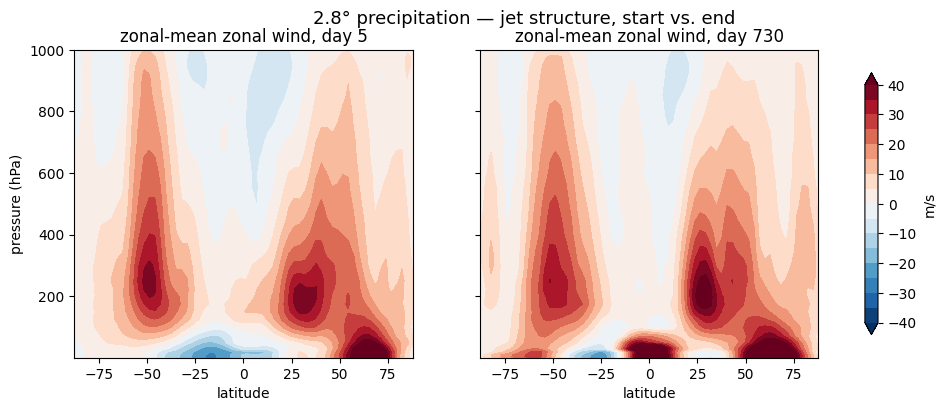

In [13]:
plot_zonal_wind(result_b, '2.8° precipitation — jet structure, start vs. end')

## What to look for

A *stable* run keeps every indicator bounded and physical for the whole
horizon: global-mean T850 and Z500 track the seasonal cycle without
runaway drift, the maximum 850-hPa wind stays at jet-stream magnitudes
(no blow-up), total column water vapour and kinetic energy stay in range,
and the zonal-mean jet retains its structure from start to end. The 2.8°
precipitation run additionally holds a realistic global-mean precipitation
rate.

The surface-pressure-drift panel is the slow one to watch: without the
`FixGlobalMeanFilter` the global mean of log surface pressure is not held
fixed and drifts a little over long runs (a small numerical effect — see
[checkpoint_modifications.ipynb](checkpoint_modifications.ipynb)). That is
exactly why the docs note that the 1.4° deterministic model's ~2-year
stability is *enhanced* by fixing the mean log surface pressure; the
stochastic models tolerate the unmodified drift over their documented
horizons.